Predictions: [0 2 1 3 1 2 0 3 2 2 3 2 2 2 3 1 0 0 1 1 3 3 1 1 2 0 3 3 1 2 2 1 2 0 2 2 3
 3 2 3 1 0 2 0 3 1 3 2 1 0 1 2 3 1 1 0 1 1 0 2 2 1 0 0 1 0 0 2 2 0 0 3 2 0
 0 1 1 0 2 2 3 3 2 2 2 0 1 0 2 3 1 0 0 3 3 1 1 0 0 2]


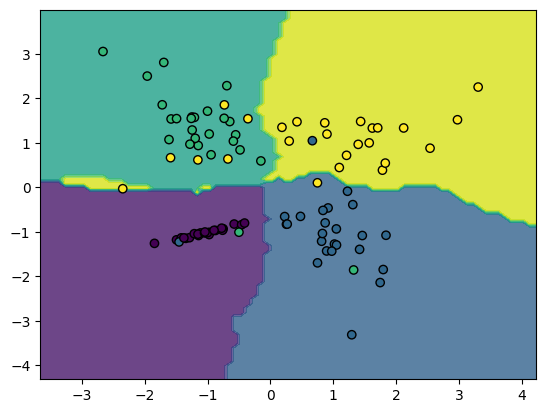

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Clustering algorithm using distance-based approach named KNN
class KNN:
    # Initialize the KNN model with the number of neighbors (k)
    def __init__(self, k=3):
        self.k = k

    # In KNN there is no training phase, it is called "laxy learning" becuase it is only storing the training data
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    # Predict the class labels for given input data
    def _predict_single(self, x):
        # Compute distances between x and all examples in the training set
        distances = np.linalg.norm(self.X_train - x, axis=1)

        # Sort by distance and return indices of the first k neighbors
        k_indices =  np.argsort(distances)[:self.k]

        # Generate the most common class among the neighbors based on votes
        k_nearest_labels = self.y_train[k_indices]
        most_common = np.bincount(k_nearest_labels).argmax()
        return most_common
    
    # Now we can predict the class lables for the entire dataset
    def predict(self, X):
        predicted_labels = [self._predict_single(x) for x in X]
        return np.array(predicted_labels)
    
    # Let's visualize the grouping of the data points based on the KNN algorithm
    def plot_decision_boundary(self, X, y):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        plt.contourf(xx, yy, Z, alpha=0.8)
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')

# Now let's implement the KNN algorithm on a simple dataset
class __main__:
    from sklearn.datasets import make_classification

    # We create a synthetic dataset
    # n_samples: The total number of samples to generate.
    # n_features: The total number of features. These are the dimensions of the data points
    # n_classes: The number of classes (or labels) to generate
    # n_informative: The number of informative features. These is useful to control the copmlexity of the dataset
    # n_redundant: The number of redundant features. Random linear combinations of the imformative features
    # n_clusters_per_class: The number of clusters per class
    # random_state: The seed used by the random number generator, which ensures reproducibility of the dataset
    X, y = make_classification(n_samples=100, n_features=2, n_classes=4, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=27)

    # Let's create the KNN model and fit it to the data
    model = KNN(k=6)
    model.fit(X, y)
    predictions = model.predict(X)
    print("Predictions:", predictions)
    model.plot_decision_boundary(X, y)